<a href="https://colab.research.google.com/github/NikhilaRaj7337/ML_Projects/blob/main/Project_Sentimental_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Sentimental Analysis Project
#Dataset from Kaggle
#Models planning to implement - SVM, LSTMS, RForest, KNN

In [1]:
#Mount input file
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#Load input file
import os

path = '/content/drive/MyDrive/Sentimental_Analysis'
file1 = os.path.join(path, 'train.csv')
file2 = os.path.join(path, 'training.1600000.processed.noemoticon.csv')

Data Preprocessing the Data

In [3]:
###DataPreprocessing
import pandas as pd

df1 = pd.read_csv(file1, encoding='latin-1') #latin-1 encoding type is used to interpret emojis, stickers in the dataset
df2 = pd.read_csv(file2, encoding='latin-1') # df2 does not have a header row

# Clean up column names by stripping leading/trailing whitespace
df1.columns = df1.columns.astype(str)
df2.columns = df2.columns.astype(str)

df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()

print(df2.columns)

Index(['polarity of tweet', 'id of the tweet', 'date of the tweet', 'query',
       'user', 'text of the tweet'],
      dtype='object')


In [4]:
#Renaming the column name of 'text of text' to 'text'
df2.rename(columns={'text of the tweet': 'text'}, inplace=True)

df = pd.concat([df1[['text']],df2[['text']]], ignore_index = True)

df.fillna('', inplace=True) ##To fill the missing values
df['text'].fillna('', inplace=True) ##To fill the missing values
df.dropna(inplace=True) ##To drop the missing values

df.describe()


/tmp/ipython-input-796449414.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['text'].fillna('', inplace=True) ##To fill the missing values


,text
count,1076053
unique,1061581
top,isPlayer Has Died! Sorry
freq,210


In [5]:
##Using a pretrained model textblob to segregate positive, negative and neutralwords

from textblob import TextBlob

def get_sentiment(text):
    analysis = TextBlob(text)
    if analysis.sentiment.polarity > 0:
      return "positive"
    elif analysis.sentiment.polarity == 0:
      return "neutral"
    else:
      return "negative"

# Fill missing values in the 'text' column with empty strings
#df['text'].fillna('', inplace=True)

df['sentiment'] = df['text'].apply(get_sentiment)

In [6]:
print(df['sentiment'].value_counts())

sentiment
positive    404293
neutral     387822
negative    283938
Name: count, dtype: int64


Data Exploring

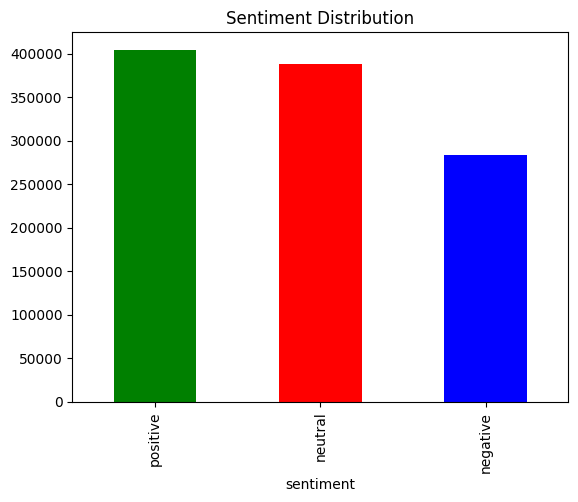

In [ ]:
##Data Exploration -- graph to visualize negative, positive and neutral words

import matplotlib.pyplot as plt

df['sentiment'].value_counts().plot(kind='bar', color=['green','red','blue'])
plt.title("Sentiment Distribution")
plt.show()


In [ ]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Text Preprocessing

In [ ]:
###Data Preprocessing
import re

df['text'] = df['text'].str.lower()
df['text'] = df['text'].apply(lambda x: re.sub(r'https\S+|www\S+|http\S+', " ", x)) #removes URL
df['text'] = df['text'].apply(lambda x: re.sub(r'#',  ' ', x) )#removes hashtag
df['text'] = df['text'].apply(lambda x: re.sub(r'@\w+', ' ', x)) #removes username
df['text'] = df['text'].apply(lambda x: re.sub(r'\d+', ' ', x)) #removes digits
df['text'] = df['text'].apply(lambda x: re.sub(r'[^\w\s]', '', x)) #removes punctuation
df['tokenized_text'] = df['text'].apply(lambda x: x.split()) ###Tokens

#Using NLTK library for stop words
stop_words = set(stopwords.words("english"))
df['tokenized_text'] = df['tokenized_text'].apply(
    lambda x: [word for word in x if word not in stop_words]
)

#Stemming(PorterStemmer library--reduces words to their root)
ps = PorterStemmer()
df['tokenized_text'] = df['tokenized_text'].apply(
    lambda x: [ps.stem(word) for word in x if word not in stop_words]
)

df['updated_text'] = df['tokenized_text'].apply(lambda x: ' '.join(x))


print(df['updated_text'].head())


0                            id respond go
1                  sooo sad miss san diego
2                               boss bulli
3                      interview leav alon
4    son couldnt put releas alreadi bought
Name: updated_text, dtype: object


Data Exploring --Polarity, Length and Word count

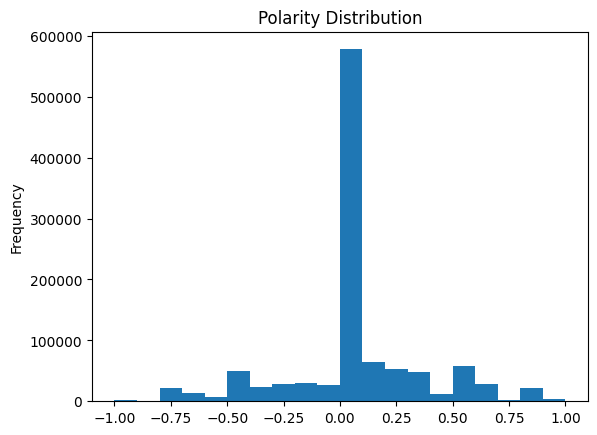

In [ ]:
###More Data Exploring

#Using TextBlob which is library for NLP
df['polarity'] = df['updated_text'].map(lambda text: TextBlob(text).sentiment.polarity)
df['subjectivity'] = df['updated_text'].map(lambda text: TextBlob(text).sentiment.subjectivity)

df['polarity'].plot(kind ='hist', bins = 20, title = 'Polarity Distribution')
plt.show()

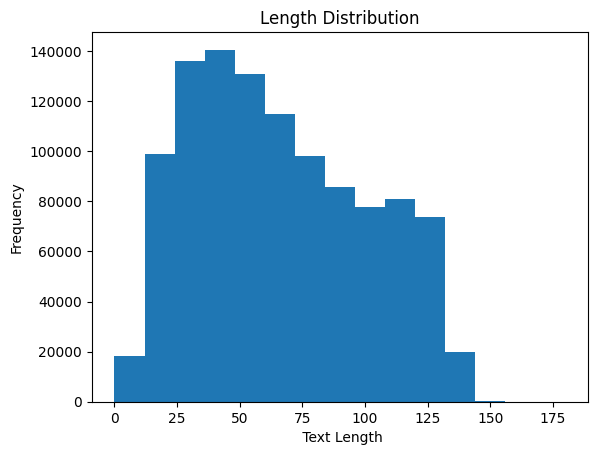

In [ ]:
##Review length
df['length'] = df['text'].astype(str).apply(len)
df['length'].plot(kind ='hist', bins = 15, title = 'Length Distribution')
plt.xlabel(' Text Length')
plt.ylabel('Frequency')
plt.show()

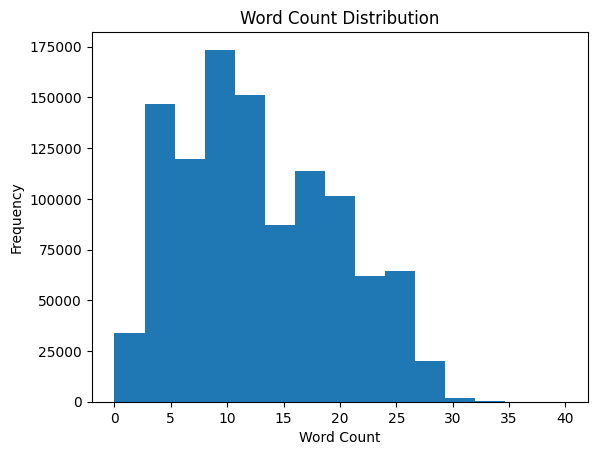

In [ ]:
##Word count
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
df['word_count'].plot(kind ='hist', bins = 15, title = 'Word Count Distribution')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.show()

N-Gram Analysis


In [ ]:
##N- gram is a technique in NLP used to analysie text by breaking the sentence into n consecutive items called n- grams

#N-gram function
def n_gram (text, n):
  n_grams = zip(*[text[i:] for i in range(n)])#creates n slices of token list and zip will convert these slices into tokens and join(gram) will make these tuples into string
  return [" ".join(gram) for gram in n_grams]

In [ ]:
# Use dropna() so the base DataFrame is not affected
Positive = df[df["sentiment"] == "positive"].dropna(subset=['text'])
Neutral = df[df["sentiment"] == "neutral"].dropna(subset=['text'])
Negative = df[df["sentiment"] == "negative"].dropna(subset=['text'])

Unigram for Positive Words

   Words  Counts
0      i  231429
1     to  169246
2    the  150509
3      a  117210
4     my   88341
5    and   85565
6    you   75237
7     it   70664
8     is   66005
9    for   63250
10    in   61552
11    of   55535
12    im   50263
13    so   49419
14   but   47681
15  have   46273
16    on   45156
17  good   44780
18    me   44391
19  that   41695


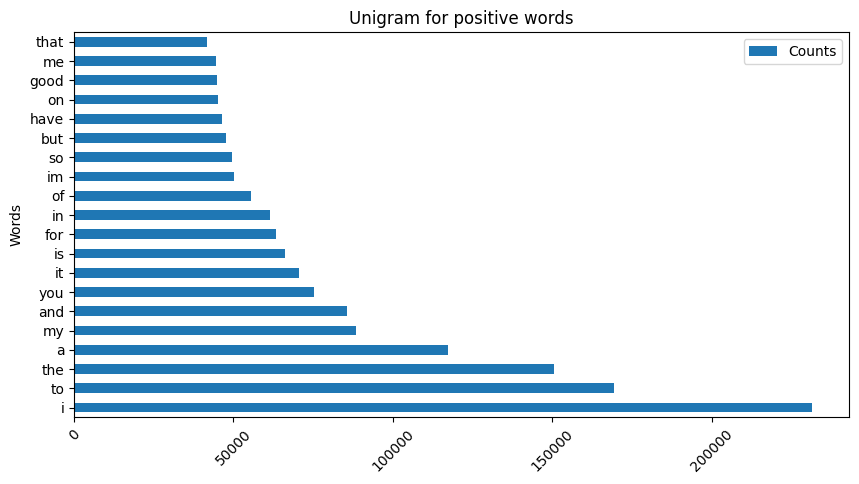

In [ ]:
all_words = []

for sentence in Positive['text']:
    tokens = sentence.split()  # simple split by whitespace (no libraries)
    #print(tokens)
    all_words.extend(tokens)

##Finding Unigram and plotting
words = n_gram(all_words, 1)
Unigram = pd.DataFrame(words, columns = ["Words"])

# Count the occurrences of each word
Unigram = Unigram['Words'].value_counts().reset_index()
Unigram.columns = ['Words', 'Counts']


top_unigram = Unigram.sort_values(by='Counts', ascending = False).head(20)
print(top_unigram)
#print(Unigram.columns)
#print(Unigram.head(20))
top_unigram.plot(kind = "barh", x='Words', y='Counts', title = "Unigram for positive words", figsize = (10, 5))
plt.xticks(rotation=45)  # rotate y-axis for readability
plt.show()

Unigram for Neutral Words

   Words  Counts
2    the  100405
3     my   77018
4      a   61117
5    and   53249
6    you   46177
7     in   45928
8     is   44604
9     it   42982
10   for   39103
11    me   37790
12    on   37708
13    of   33375
14  have   30916
15    im   30093
16  just   25914
17    at   24370
18   but   23998
19  that   22867
20   not   22581
21  with   21428
22    no   21219
23    up   19180
24  work   19150
25    go   19067
26  cant   18872
27    be   18824
28  dont   18448
29   out   18379


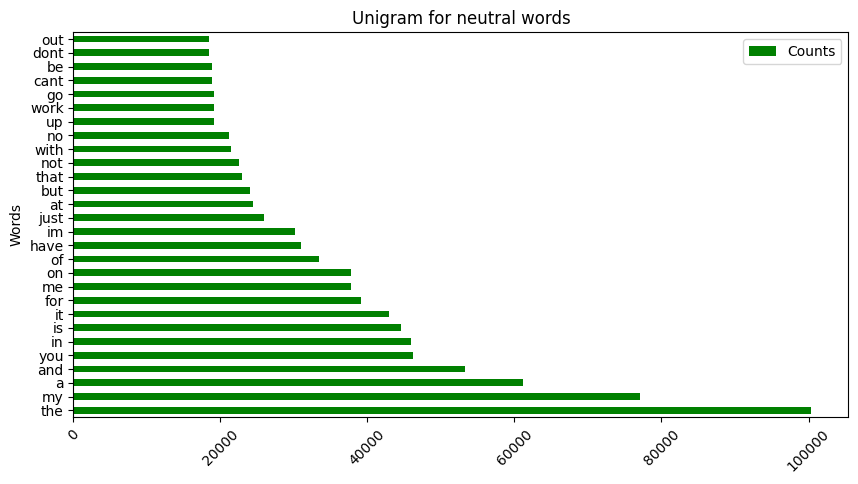

In [ ]:
all_words = []

for sentence in Neutral['text']:
    tokens = sentence.split()  # simple split by whitespace (no libraries)
    #print(tokens)
    all_words.extend(tokens)

##Finding Unigram and plotting
words = n_gram(all_words, 1)
Unigram = pd.DataFrame(words, columns = ["Words"])

# Count the occurrences of each word
Unigram = Unigram['Words'].value_counts().reset_index()
Unigram.columns = ['Words', 'Counts']


Unigram= Unigram.sort_values(by='Counts', ascending = False).reset_index(drop = True)
mid_unigram = Unigram.iloc[2:30]
print(mid_unigram)
#print(Unigram.columns)
#print(Unigram.head(20))
mid_unigram.plot(kind = "barh", x='Words', y='Counts', title = "Unigram for neutral words", color = 'green', figsize = (10, 5))
plt.xticks(rotation=45)  # rotate x-axis for readability
plt.show()

Unigram for Negative Words

   Words  Counts
0      i  162569
1     to  109729
2    the   95828
3      a   75499
4     my   67692
5    and   63586
6     is   55329
7     im   48010
8     it   44791
9     so   41924
10    in   41880
11   for   36839
12    of   35499
13   you   32627
14    me   32366
15  that   32079
16   not   30104
17    on   29716
18  have   27890
19   but   26637


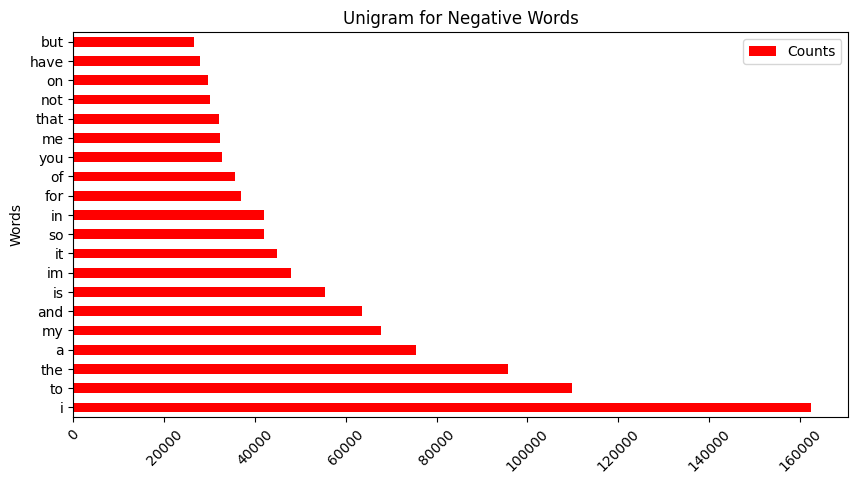

In [ ]:
all_words = []

for sentence in Negative['text']:
    tokens = sentence.split()  # simple split by whitespace (no libraries)
    #print(tokens)
    all_words.extend(tokens)

##Finding Unigram and plotting
words = n_gram(all_words, 1)
Unigram = pd.DataFrame(words, columns = ["Words"])

# Count the occurrences of each word
Unigram = Unigram['Words'].value_counts().reset_index()
Unigram.columns = ['Words', 'Counts']


Unigram= Unigram.sort_values(by='Counts', ascending = False).head(20)
print(Unigram)
#print(Unigram.columns)
#print(Unigram.head(20))
Unigram.plot(kind = "barh", x='Words', y='Counts', title = "Unigram for Negative Words", color = 'red', figsize = (10, 5))
plt.xticks(rotation=45)  # rotate x-axis for readability
plt.show()

Bigram of Review for the Sentiments

       Words  Counts
0     i have   13288
1     i love   12741
2     in the   12714
3   going to   10683
4      to be   10506
5    for the   10456
6     i dont   10159
7      but i   10057
8       i am   10056
9      to go    9647
10    have a    9580
11     i was    9259
12   have to    9016
13    a good    8417
14     and i    8284
15    i cant    7880
16    on the    7867
17    to the    7768
18    of the    7460
19   so much    7303


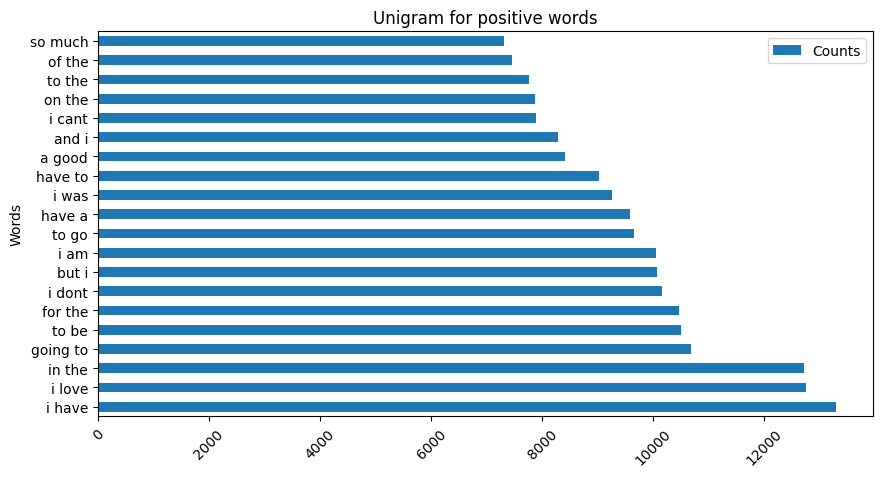

In [ ]:
### Plot for Bigram for Positive Reviews

all_words = []

for sentence in Positive['text']:
    tokens = sentence.split()  # simple split by whitespace (no libraries)
    #print(tokens)
    all_words.extend(tokens)

##Finding Unigram and plotting
words = n_gram(all_words, 2)
Unigram = pd.DataFrame(words, columns = ["Words"])

# Count the occurrences of each word
Unigram = Unigram['Words'].value_counts().reset_index()
Unigram.columns = ['Words', 'Counts']


top_unigram = Unigram.sort_values(by='Counts', ascending = False).head(20)
print(top_unigram)
#print(Unigram.columns)
#print(Unigram.head(20))
top_unigram.plot(kind = "barh", x='Words', y='Counts', title = "Unigram for positive words", figsize = (10, 5))
plt.xticks(rotation=45)  # rotate y-axis for readability
plt.show()

Bigram for Neutral Words

       Words  Counts
0     i have   13288
1     i love   12741
2     in the   12714
3   going to   10683
4      to be   10506
5    for the   10456
6     i dont   10159
7      but i   10057
8       i am   10056
9      to go    9647
10    have a    9580
11     i was    9259
12   have to    9016
13    a good    8417
14     and i    8284
15    i cant    7880
16    on the    7867
17    to the    7768
18    of the    7460
19   so much    7303


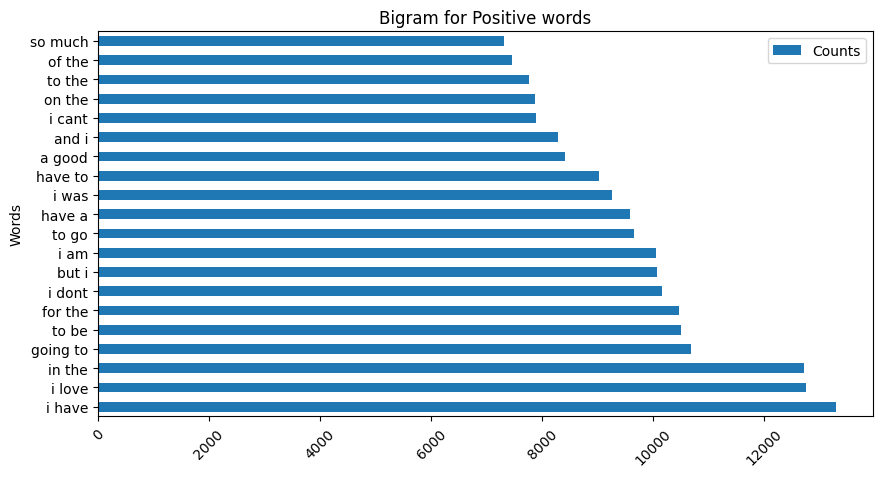

In [ ]:
### Plot for Bigram for Positive Reviews

all_words = []

for sentence in Positive['text']:
    tokens = sentence.split()  # simple split by whitespace (no libraries)
    #print(tokens)
    all_words.extend(tokens)

##Finding Unigram and plotting
words = n_gram(all_words, 2)
Unigram = pd.DataFrame(words, columns = ["Words"])

# Count the occurrences of each word
Unigram = Unigram['Words'].value_counts().reset_index()
Unigram.columns = ['Words', 'Counts']


top_unigram = Unigram.sort_values(by='Counts', ascending = False).head(20)
print(top_unigram)
#print(Unigram.columns)
#print(Unigram.head(20))
top_unigram.plot(kind = "barh", x='Words', y='Counts', title = "Bigram for Positive words", figsize = (10, 5))
plt.xticks(rotation=45)  # rotate y-axis for readability
plt.show()

Bigram for Negative Words

       Words  Counts
0     i hate   12310
1     i have   10585
2       i am    8834
3     in the    8724
4   going to    7889
5     i dont    6950
6      and i    6876
7     i cant    6809
8    have to    6807
9      to be    6632
10     to go    6301
11     i was    6186
12    i feel    5986
13     but i    5396
14    to the    5394
15    on the    5388
16   i think    5010
17     im so    4855
18   for the    4822
19    to get    4799


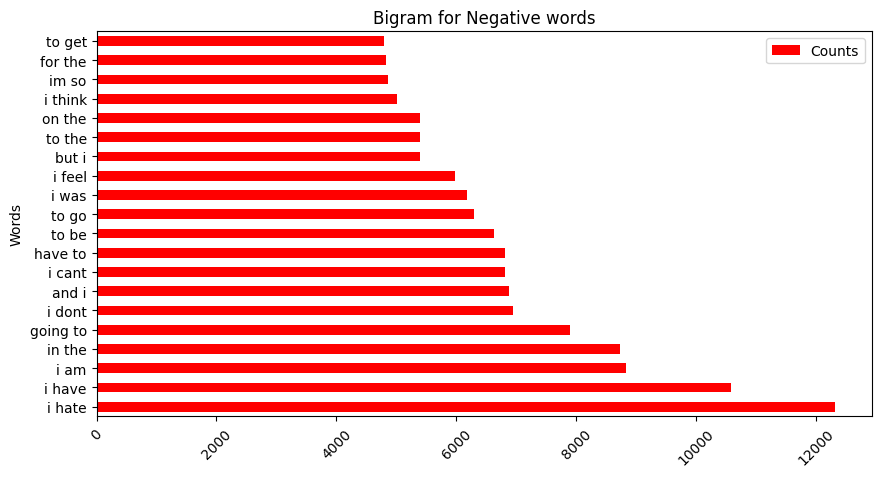

In [ ]:
### Plot for Bigram for Positive Reviews

all_words = []

for sentence in Negative['text']:
    tokens = sentence.split()  # simple split by whitespace (no libraries)
    #print(tokens)
    all_words.extend(tokens)

##Finding Unigram and plotting
words = n_gram(all_words, 2)
Unigram = pd.DataFrame(words, columns = ["Words"])

# Count the occurrences of each word
Unigram = Unigram['Words'].value_counts().reset_index()
Unigram.columns = ['Words', 'Counts']


top_unigram = Unigram.sort_values(by='Counts', ascending = False).head(20)
print(top_unigram)
#print(Unigram.columns)
#print(Unigram.head(20))
top_unigram.plot(kind = "barh", x='Words', y='Counts', title = "Bigram for Negative words", color = 'red', figsize = (10, 5))
plt.xticks(rotation=45)  # rotate y-axis for readability
plt.show()

      Words  Counts
2    i dont   10038
3    in the    9857
4    i cant    8988
5    i miss    8265
6   have to    7905
7     to go    7799
8    to the    7131
9   want to    7032
10   i want    6902
11    i was    6850
12   on the    6586
13    and i    5948
14     i am    5869
15    go to    5839
16    but i    5795
17   wish i    5755
18   i wish    5612
19  to work    5583
20    to be    5294
21  for the    5194
22    on my    5167
23  i think    4897
24   to get    4897
25  back to    4862
26   i just    4805
27   at the    4686
28   of the    4610
29    to do    4529


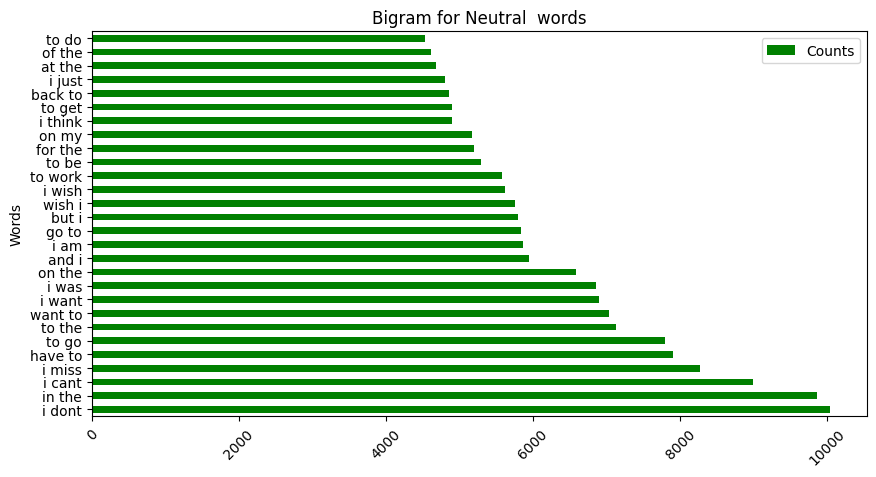

In [ ]:
### Plot for Bigram for Positive Reviews

all_words = []

for sentence in Neutral['text']:
    tokens = sentence.split()  # simple split by whitespace (no libraries)
    #print(tokens)
    all_words.extend(tokens)

##Finding Unigram and plotting
words = n_gram(all_words, 2)
Unigram = pd.DataFrame(words, columns = ["Words"])

# Count the occurrences of each word
Unigram = Unigram['Words'].value_counts().reset_index()
Unigram.columns = ['Words', 'Counts']


Unigram.sort_values(by='Counts', ascending = False).reset_index(drop = True)
mid_unigram = Unigram.iloc[2:30]
print(mid_unigram)
#print(Unigram.columns)
#print(Unigram.head(20))
mid_unigram.plot(kind = "barh", x='Words', y='Counts', title = "Bigram for Neutral  words", color = 'Green', figsize = (10, 5))
plt.xticks(rotation=45)  # rotate y-axis for readability
plt.show()

Triigram for Positive Words

                 Words  Counts
0            i have to    3688
1             to go to    3181
2             i wish i    3164
3    happy mothers day    2562
4           i love you    2560
5       thanks for the    2465
6         wish i could    2277
7            i want to    2224
8           be able to    2075
9             i have a    1987
10         im going to    1942
11           i need to    1888
12         going to be    1870
13          wish i was    1548
14           i think i    1440
15        have a great    1422
16         i dont have    1419
17         i dont know    1418
18  looking forward to    1364
19          i miss you    1350


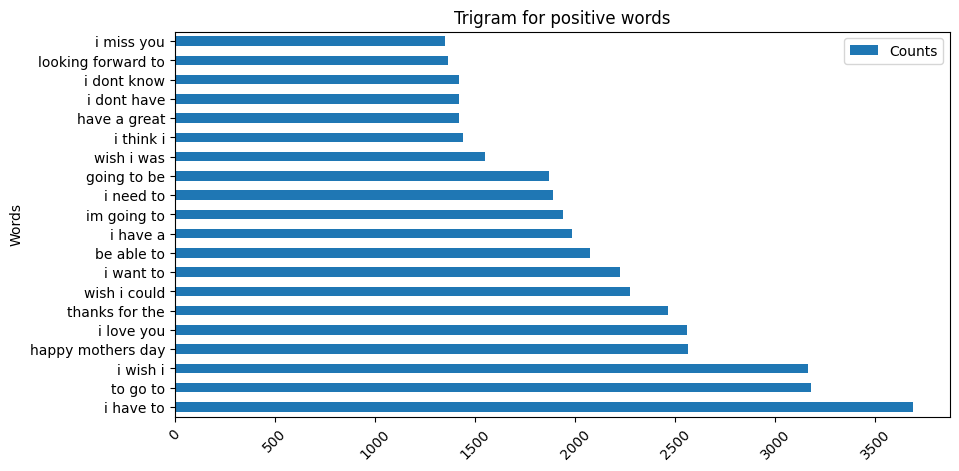

In [ ]:
### Plot for Bigram for Positive Reviews

all_words = []

for sentence in Positive['text']:
    tokens = sentence.split()  # simple split by whitespace (no libraries)
    #print(tokens)
    all_words.extend(tokens)

##Finding Unigram and plotting
words = n_gram(all_words, 3)
Unigram = pd.DataFrame(words, columns = ["Words"])

# Count the occurrences of each word
Unigram = Unigram['Words'].value_counts().reset_index()
Unigram.columns = ['Words', 'Counts']


top_unigram = Unigram.sort_values(by='Counts', ascending = False).head(20)
print(top_unigram)
#print(Unigram.columns)
#print(Unigram.head(20))
top_unigram.plot(kind = "barh", x='Words', y='Counts', title = "Trigram for positive words", figsize = (10, 5))
plt.xticks(rotation=45)  # rotate y-axis for readability
plt.show()

            Words  Counts
0       i have to    2884
1        to go to    2215
2        i have a    2043
3   sorry to hear    2031
4       i want to    1908
5     going to be    1540
6     im going to    1468
7        i wish i    1380
8         i am so    1362
9       i need to    1349
10    i feel like    1344
11   to hear that    1203
12      i think i    1199
13    i dont know    1186
14     want to go    1087
15      i hate it    1026
16   dont want to     992
17   wish i could     987
18    is going to     964
19      i feel so     940


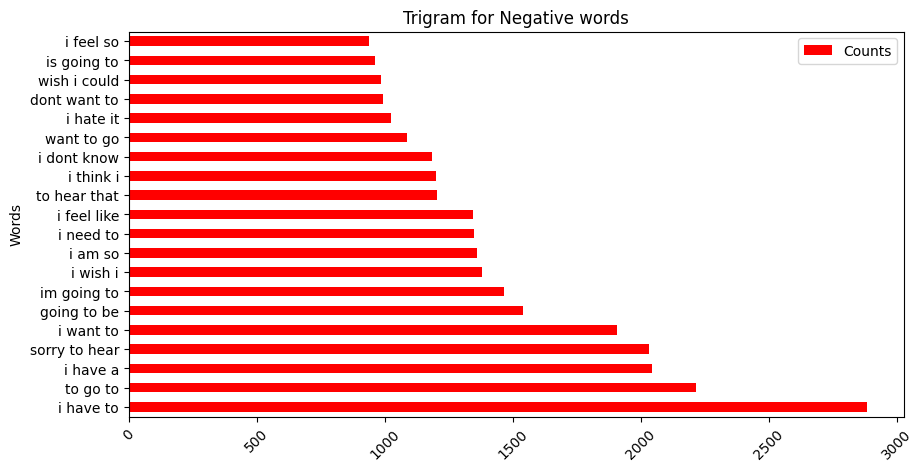

In [ ]:
### Plot for Trigram for Positive Reviews

all_words = []

for sentence in Negative['text']:
    tokens = sentence.split()  # simple split by whitespace (no libraries)
    #print(tokens)
    all_words.extend(tokens)

##Finding Unigram and plotting
words = n_gram(all_words, 3)
Unigram = pd.DataFrame(words, columns = ["Words"])

# Count the occurrences of each word
Unigram = Unigram['Words'].value_counts().reset_index()
Unigram.columns = ['Words', 'Counts']


top_unigram = Unigram.sort_values(by='Counts', ascending = False).head(20)
print(top_unigram)
#print(Unigram.columns)
#print(Unigram.head(20))
top_unigram.plot(kind = "barh", x='Words', y='Counts', title = "Trigram for Negative words", color = 'red', figsize = (10, 5))
plt.xticks(rotation=45)  # rotate y-axis for readability
plt.show()

                 Words  Counts
2            i want to    2981
3             to go to    2941
4         wish i could    2088
5           i miss you    1957
6             i have a    1840
7            i miss my    1838
8          i dont know    1797
9          im going to    1785
10          want to go    1766
11          wish i was    1679
12           i need to    1648
13        dont want to    1618
14         i dont want    1569
15         i dont have    1381
16  looking forward to    1354
17           i think i    1288
18         is going to    1235
19           go to the    1170
20          have to go    1073
21           i have no    1042
22        back to work    1001
23        i dont think     985
24            i need a     957
25         going to be     943
26          go back to     933
27         i feel like     916
28           on my way     910
29          go to work     868


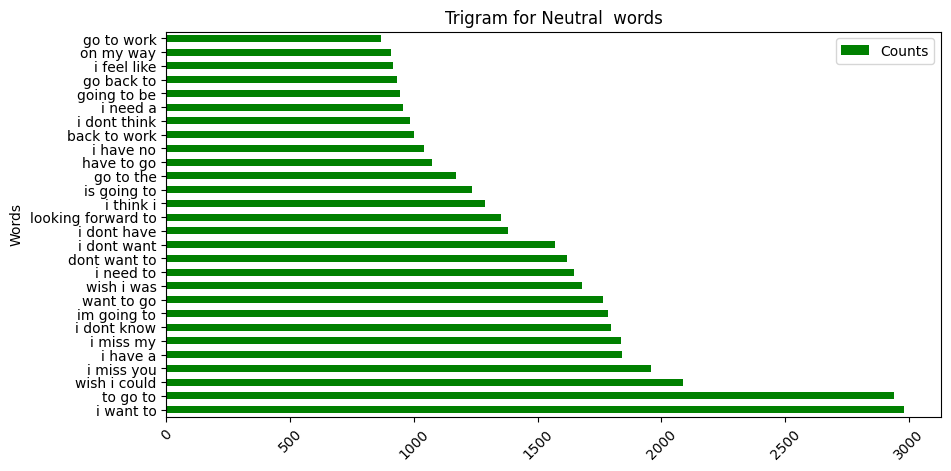

In [ ]:
### Plot for Trigram for Neutral Reviews

all_words = []

for sentence in Neutral['text']:
    tokens = sentence.split()  # simple split by whitespace (no libraries)
    #print(tokens)
    all_words.extend(tokens)

##Finding Unigram and plotting
words = n_gram(all_words, 3)
Unigram = pd.DataFrame(words, columns = ["Words"])

# Count the occurrences of each word
Unigram = Unigram['Words'].value_counts().reset_index()
Unigram.columns = ['Words', 'Counts']


Unigram.sort_values(by='Counts', ascending = False).reset_index(drop = True)
mid_unigram = Unigram.iloc[2:30]
print(mid_unigram)
#print(Unigram.columns)
#print(Unigram.head(20))
mid_unigram.plot(kind = "barh", x='Words', y='Counts', title = "Trigram for Neutral  words", color = 'Green', figsize = (10, 5))
plt.xticks(rotation=45)  # rotate y-axis for readability
plt.show()

Word Clouds

In [ ]:
#######Word cloud can visually highlight frequent words within a text, with size representing frequency, and can be enhanced by coloring words based on their sentiment (positive/negative/neutral)

In [ ]:
from collections import Counter
import random

all_words = " ".join(df["updated_text"]).split()
word_freq = Counter(all_words)
#word_freq = dict(word_freq)

plt.figure(figsize=(5,5))
for word, count in word_freq.items():
    # Random position
    x, y = random.random(), random.random()
    # Font size proportional to frequency
    plt.text(x, y, word, fontsize=3 + count, alpha=0.7)

plt.axis("off")
plt.show()


Word Cloud for Positive Words

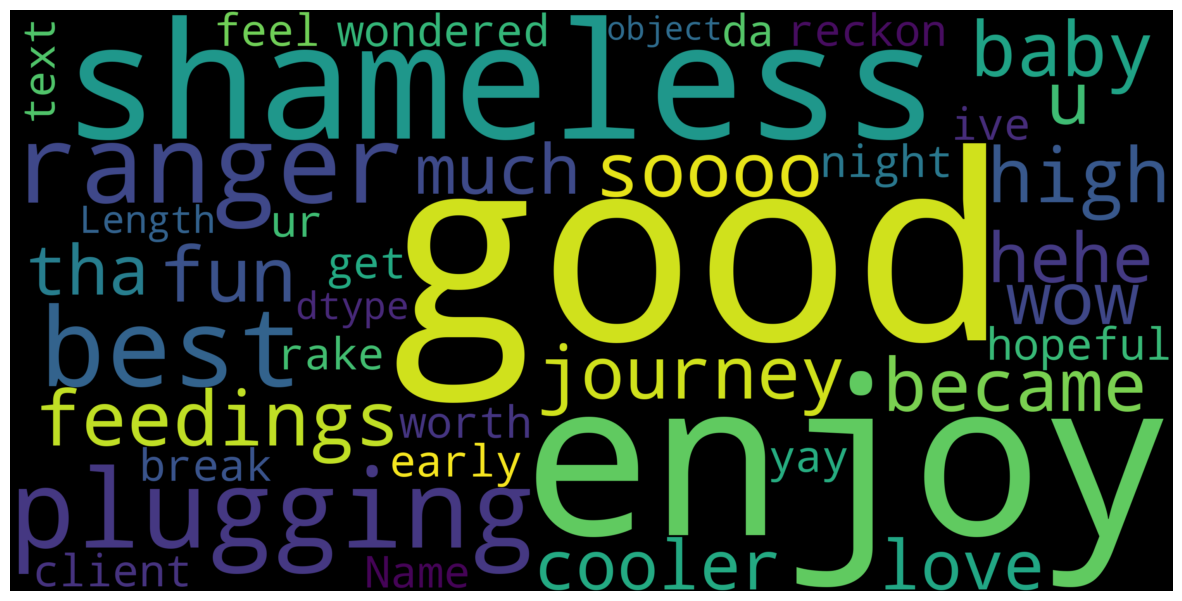

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordCloud = WordCloud(max_words = 50, width = 3000, height = 1500, stopwords = stop_words).generate(str(Positive["text"]))
plt.figure(figsize = (15, 15))
plt.imshow(wordCloud, interpolation = "bilinear")
plt.axis("off")
plt.show()

Word Cloud for Negative Words

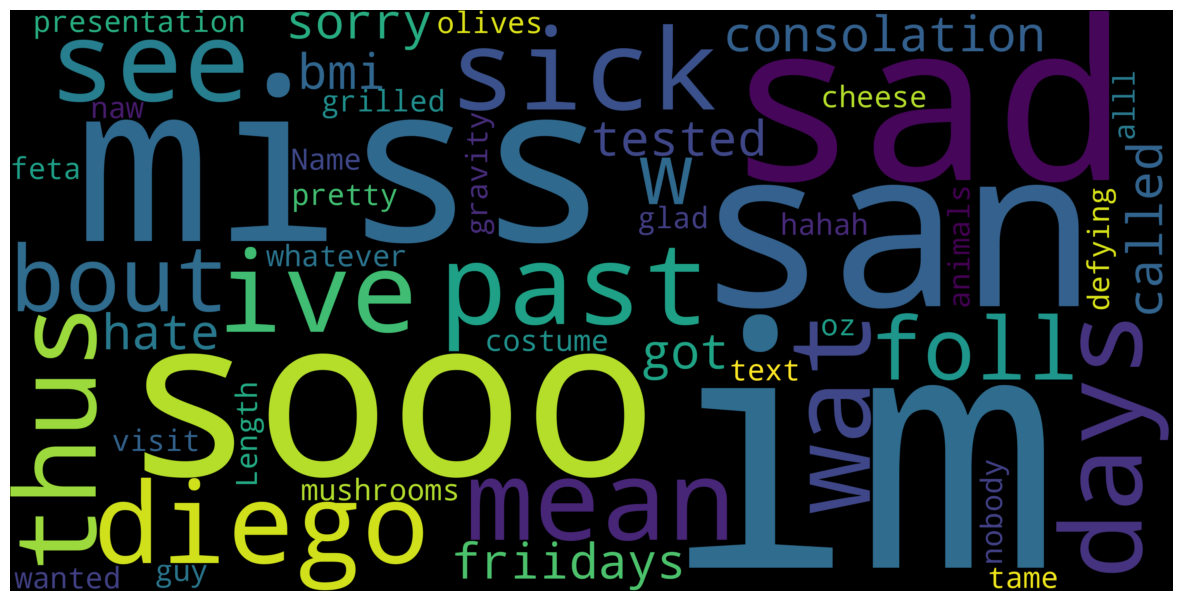

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordCloud = WordCloud(max_words = 50, width = 3000, height = 1500, stopwords = stop_words).generate(str(Negative["text"]))
plt.figure(figsize = (15, 15))
plt.imshow(wordCloud, interpolation = "bilinear")
plt.axis("off")
plt.show()

Word Cloud for Neutral Words

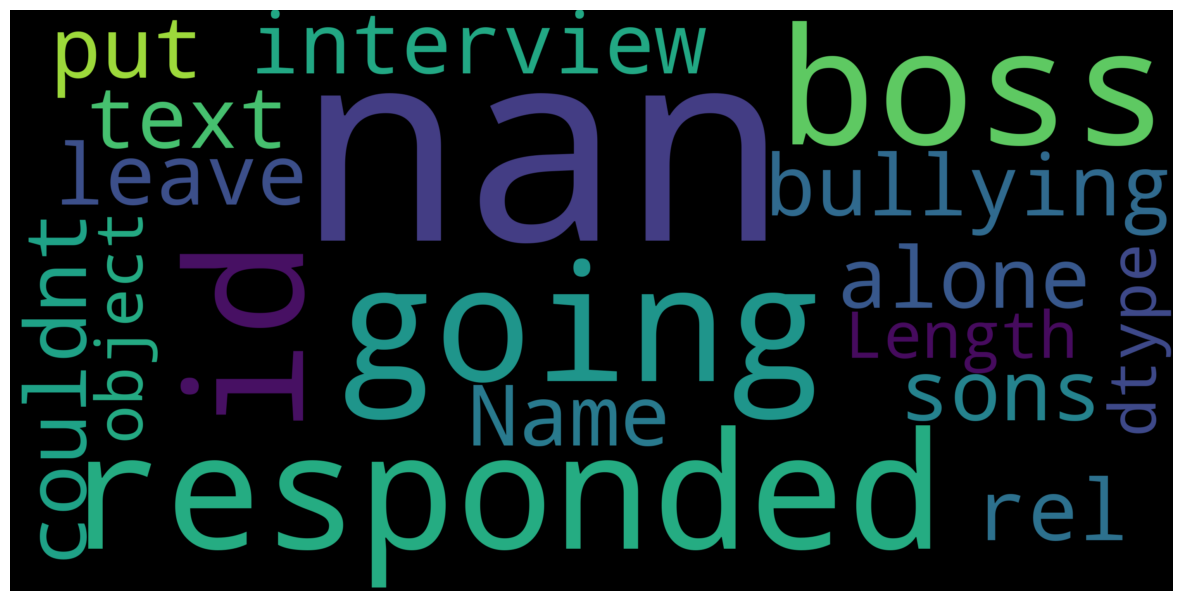

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordCloud = WordCloud(max_words = 50, width = 3000, height = 1500, stopwords = stop_words).generate(str(Neutral["text"]))
plt.figure(figsize = (15, 15))
plt.imshow(wordCloud, interpolation = "bilinear")
plt.axis("off")
plt.show()

# **Feature Engineering**


Drop Insignificant Columuns

In [7]:
print(df1.columns)
print(df2.columns)
print(df.columns)

Index(['textID', 'text', 'selected_text', 'sentiment', 'Time of Tweet',
       'Age of User', 'Country', 'Population -2020', 'Land Area (Km²)',
       'Density (P/Km²)'],
      dtype='object')
Index(['polarity of tweet', 'id of the tweet', 'date of the tweet', 'query',
       'user', 'text'],
      dtype='object')
Index(['text', 'sentiment'], dtype='object')


In [9]:
print(df.columns)
df.head(3)

Index(['text', 'sentiment'], dtype='object')


,text,sentiment
0,"I`d have responded, if I were going",neutral
1,Sooo SAD I will miss you here in San Diego!!!,negative
2,my boss is bullying me...,neutral


Encoding our Target Variable

In [10]:
from sklearn.preprocessing import LabelEncoder

Encoder = LabelEncoder()
df["sentiment"] = Encoder.fit_transform(df["sentiment"])
df["sentiment"].value_counts()

,count
sentiment,
2,404293
1,387822
0,283938


TF-IDF Vectorization

In [11]:
# TF-IDF Vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Defining our vectorizer with total words of 5000 and with bigram model
TF_IDF = TfidfVectorizer(max_features = 5000, ngram_range = (2, 2))

# Fitting and transforming our reviews into a matrix of weighed words
# This will be our independent features
X = TF_IDF.fit_transform(df["text"])

# Check our matrix shape
X.shape


# Declaring our target variable
y = df["sentiment"]

Resampling Our Dataset

*We are using bootstrap method for resampling the dataset. We can also use SMOTE method to resample our dataset*

In [12]:
from collections import Counter

Counter(y)

Counter({1: 387822, 0: 283938, 2: 404293})

In [13]:
import numpy as np
from sklearn.utils import resample
from scipy.sparse import vstack

# Find unique class labels
classes = np.unique(y)

# Find maximum class size
max_class_size = y.value_counts().max()

# Create lists to hold resampled data
X_resampled_list = []
y_resampled_list = []

# Bootstrap resample each class
for label in classes:
    # Get indices for this class
    class_idx = np.where(y == label)[0]

    # Bootstrap sample indices
    resampled_idx = resample(class_idx,
                             replace=True,
                             n_samples=max_class_size,
                             random_state=42)

    # Append resampled data
    X_resampled_list.append(X[resampled_idx])
    y_resampled_list.append(y.iloc[resampled_idx])

# Combine all upsampled data
from scipy.sparse import vstack
X_final = vstack(X_resampled_list)
y_final = np.concatenate(y_resampled_list)

print("Before:", y.value_counts().to_dict())
print("After:", {label: sum(y_final == label) for label in np.unique(y_final)})



Before: {2: 404293, 1: 387822, 0: 283938}
After: {np.int64(0): np.int64(404293), np.int64(1): np.int64(404293), np.int64(2): np.int64(404293)}


In [14]:
Counter(y_final)

Counter({np.int64(0): 404293, np.int64(1): 404293, np.int64(2): 404293})

Splitting Our Dataset

In [15]:
# Splitting Dataset
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size = 0.25, random_state = 42)

Model Building & Evaluation

In [16]:
###Libraries for Model Building
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score


In [17]:
DTree = DecisionTreeClassifier()
LogReg = LogisticRegression()

In [18]:

RForest = RandomForestClassifier()
Bayes = BernoulliNB()
KNN = KNeighborsClassifier()

Training the Models

In [ ]:
Models = [DTree, LogReg, RForest, Bayes, KNN]
Models_Dict = {0: "Decision Tree", 1: "Logistic Regression", 2: "Random Forest", 3: "Naive Bayes", 4: "K-Neighbors"}

for i, model in enumerate(Models):
   print(f"Running cross-validation for {Models_Dict[i]} ...")
   score = cross_val_score(model, X, y, cv=3, scoring="accuracy").mean()
   print(f"{Models_Dict[i]} Test Accuracy: {score}")


Running cross-validation for Decision Tree ...
Decision Tree Test Accuracy: 0.6226793619567483
Running cross-validation for Logistic Regression ...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Logistic Regression Test Accuracy: 0.6703461609021201
Running cross-validation for Random Forest ...


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

RF = RandomForestClassifier(
    n_estimators=50,       # fewer trees
    max_depth=10,          # limit tree depth
    n_jobs=-1,             # use all CPU cores
    random_state=42
)

print("Running cross-validation for Random Forest (optimized)...")
rf_score = cross_val_score(RF, X, y, cv=3, scoring="accuracy")
print("Random Forest Test Accuracy:", rf_score.mean())


Running cross-validation for Random Forest (optimized)...
Random Forest Test Accuracy: 0.3905458198578197


In [ ]:
from sklearn.model_selection import cross_val_score

# --- Naive Bayes ---
print("Running cross-validation for Naive Bayes ...")
bayes_score = cross_val_score(Bayes, X, y, cv=3, scoring="accuracy", n_jobs=-1).mean()
print(f"Naive Bayes Test Accuracy: {bayes_score:.4f}")

# --- K-Nearest Neighbors ---
print("Running cross-validation for K-Neighbors ...")
knn_score = cross_val_score(KNN, X, y, cv=2, scoring="accuracy", n_jobs=-1).mean()
print(f"K-Neighbors Test Accuracy: {knn_score:.4f}")


Running cross-validation for Naive Bayes ...
Naive Bayes Test Accuracy: 0.6461
Running cross-validation for K-Neighbors ...
K-Neighbors Test Accuracy: 0.5038


In [37]:
from xgboost import XGBClassifier
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_score = cross_val_score(xgb, X, y, cv=3, scoring='accuracy').mean()
print(f"XGBoost Test Accuracy: {xgb_score:.4f}")


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [20:32:38] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [20:37:32] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [20:41:48] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Test Accuracy: 0.6114


Hyperparameter Tuning

In [29]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    LogisticRegression(random_state=42),
    param_distributions=param_grid,
    n_iter=1,  # number of random combinations to try
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=3  # Add this to see detailed progress in console
)

random_search.fit(X_train, y_train)


Fitting 3 folds for each of 1 candidates, totalling 3 fits


RandomizedSearchCV(cv=3, estimator=LogisticRegression(random_state=42),
                   n_iter=1, n_jobs=-1,
                   param_distributions={'C': [0.001, 0.01, 0.1, 1, 10, 100],
                                        'max_iter': [100, 200],
                                        'penalty': ['l2', 'l1'],
                                        'solver': ['liblinear', 'saga']},
                   random_state=42, scoring='accuracy', verbose=3)

In [31]:
random_search.fit(X_train, y_train)

print("Best parameters found:", random_search.best_params_)
print(f"Best cross-validation accuracy: {random_search.best_score_:.4f}")


Fitting 3 folds for each of 1 candidates, totalling 3 fits
Best parameters found: {'solver': 'saga', 'penalty': 'l1', 'max_iter': 100, 'C': 1}
Best cross-validation accuracy: 0.6566


Best Model

In [33]:
Classifier = LogisticRegression(random_state = 42, C = 1, penalty = 'l2')
Classifier.fit(X_train, y_train)

Prediction = Classifier.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Metrics--- Accuracy and Confusion Matrix

In [34]:
accuracy_score(y_test, Prediction)

0.6575984433744476

In [35]:

ConfusionMatrix = confusion_matrix(y_test, Prediction)

In [38]:
import matplotlib.pyplot as plt
# Plotting Function for Confusion Matrix
def plot_cm(cm, classes, title, normalized = False, cmap = plt.cm.Blues):

  plt.imshow(cm, interpolation = "nearest", cmap = cmap)
  plt.title(title, pad = 20)
  plt.colorbar()
  tick_marks = np.arange(len(classes))
  plt.xticks(tick_marks, classes)
  plt.yticks(tick_marks, classes)

  if normalized:
    cm = cm.astype('float') / cm.sum(axis = 1)[: np.newaxis]
    print("Normalized Confusion Matrix")
  else:
    print("Unnormalized Confusion Matrix")

  threshold = cm.max() / 2
  for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
      plt.text(j, i, cm[i, j], horizontalalignment = "center", color = "white" if cm[i, j] > threshold else "black")

  plt.tight_layout()
  plt.xlabel("Predicted Label", labelpad = 20)
  plt.ylabel("Real Label", labelpad = 20)

Unnormalized Confusion Matrix


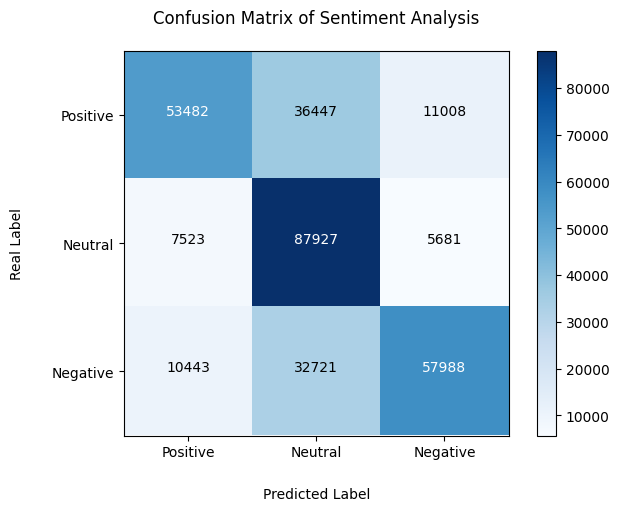

In [39]:
plot_cm(ConfusionMatrix, classes = ["Positive", "Neutral", "Negative"], title = "Confusion Matrix of Sentiment Analysis")

Classification Scores

In [40]:
print(classification_report(y_test, Prediction))

              precision    recall  f1-score   support

           0       0.75      0.53      0.62    100937
           1       0.56      0.87      0.68    101131
           2       0.78      0.57      0.66    101152

    accuracy                           0.66    303220
   macro avg       0.69      0.66      0.65    303220
weighted avg       0.69      0.66      0.65    303220

